# Module 13 — Data Visualization

Visualize employee attrition patterns and key HR metrics.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

print("Libraries imported successfully.")

Libraries imported successfully.


## Load Clean Dataset

In [ ]:
df = pd.read_csv("../data/processed/employee_hr_analytics_clean.csv")

print("Dataset shape:", df.shape)

df.head()

Dataset shape: (1000, 22)


,Employee_ID,Age,Gender,Department,Job_Role,Experience,Education,Salary,Performance_Score,Job_Satisfaction,...,Remote_Work,Training_Hours,Projects,Promotion_Last_5Yrs,Joining_Date,Attrition,City,Employment_Type,Manager_Rating,Sick_Leaves
0,1,40.0,Male,Sales,Sales Manager,3,Master,94113.0,5,6.0,...,No,70,5,No,2011-12-21,No,Rawalpindi,Contract,5,6
1,2,39.0,Female,Sales,Sales Manager,2,Master,54224.0,4,9.0,...,No,33,3,Yes,2015-09-20,No,Islamabad,Full-Time,4,4
2,3,49.0,Male,Finance,Financial Analyst,25,Master,166749.0,2,6.0,...,Yes,75,12,No,2014-12-10,No,Islamabad,Full-Time,8,2
3,4,54.0,Female,Marketing,Marketing Specialist,26,Bachelor,196590.0,5,4.0,...,Yes,64,12,No,2022-08-23,Yes,Rawalpindi,Contract,4,5
4,5,41.0,Female,IT,Data Analyst,18,PhD,231764.0,3,8.0,...,Yes,15,12,No,2021-09-29,No,Rawalpindi,Contract,10,8


In [3]:
print("Columns:")

for column in df.columns:
    print(column)

Columns:
Employee_ID
Age
Gender
Department
Job_Role
Experience
Education
Salary
Performance_Score
Job_Satisfaction
Overtime
Work_Hours
Remote_Work
Training_Hours
Projects
Promotion_Last_5Yrs
Joining_Date
Attrition
City
Employment_Type
Manager_Rating
Sick_Leaves


## Basic Dataset Validation

In [4]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

print("\nMissing values:")
print(df.isnull().sum().sum())

print("\nDuplicate rows:")
print(df.duplicated().sum())

Rows: 1000
Columns: 22

Missing values:
0

Duplicate rows:
0


## Attrition Distribution

In [5]:
attrition_counts = df["Attrition"].value_counts()

print(attrition_counts)

Attrition
No     882
Yes    118
Name: count, dtype: int64


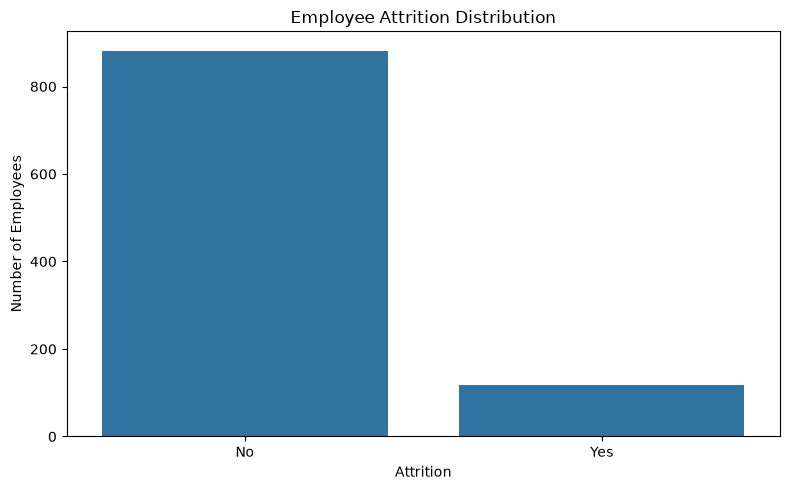

In [6]:
plt.figure(figsize=(8, 5))

sns.countplot(data=df, x="Attrition")

plt.title("Employee Attrition Distribution")
plt.xlabel("Attrition")
plt.ylabel("Number of Employees")

plt.tight_layout()
plt.show()

## Attrition Rate

In [7]:
total_employees = len(df)

employees_left = (df["Attrition"] == "Yes").sum()

attrition_rate = (employees_left / total_employees) * 100

print("Total Employees:", total_employees)
print("Employees Left:", employees_left)
print("Attrition Rate:", round(attrition_rate, 2), "%")

Total Employees: 1000
Employees Left: 118
Attrition Rate: 11.8 %


## Attrition by Department

In [8]:
department_analysis = (
    df.groupby("Department")
    .agg(
        Total_Employees=("Employee_ID", "count"),
        Employees_Left=("Attrition", lambda x: (x == "Yes").sum()),
    )
    .reset_index()
)

department_analysis["Attrition_Rate"] = (
    department_analysis["Employees_Left"] / department_analysis["Total_Employees"]
) * 100

department_analysis = department_analysis.sort_values("Attrition_Rate", ascending=False)

department_analysis

,Department,Total_Employees,Employees_Left,Attrition_Rate
3,Marketing,196,29,14.795918
2,IT,182,23,12.637363
4,Sales,199,25,12.562814
1,HR,229,24,10.480349
0,Finance,194,17,8.762887


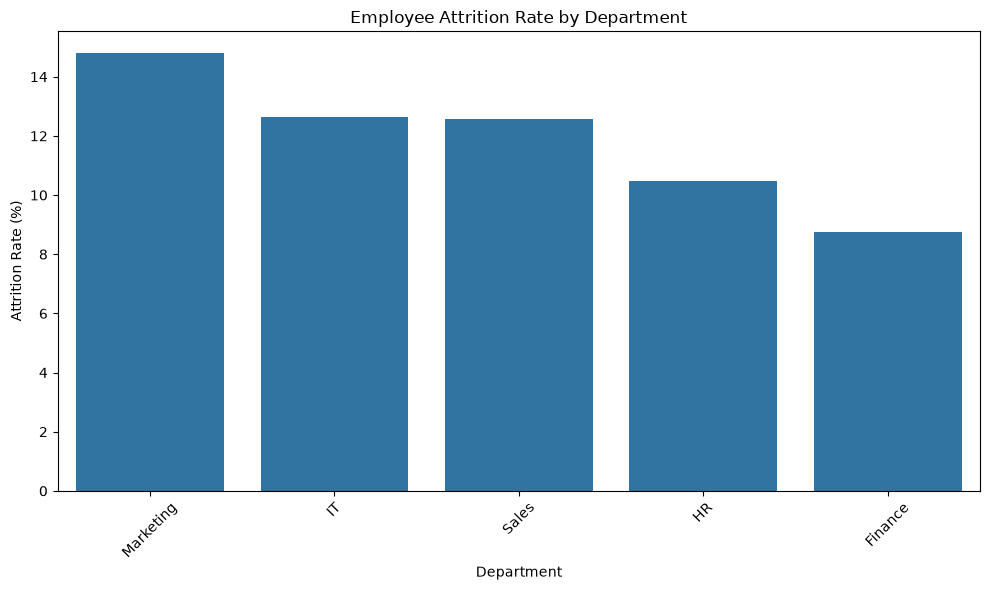

In [9]:
plt.figure(figsize=(10, 6))

sns.barplot(data=department_analysis, x="Department", y="Attrition_Rate")

plt.title("Employee Attrition Rate by Department")
plt.xlabel("Department")
plt.ylabel("Attrition Rate (%)")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## Attrition by Job Role

In [10]:
role_analysis = (
    df.groupby("Job_Role")
    .agg(
        Total_Employees=("Employee_ID", "count"),
        Employees_Left=("Attrition", lambda x: (x == "Yes").sum()),
    )
    .reset_index()
)

role_analysis["Attrition_Rate"] = (
    role_analysis["Employees_Left"] / role_analysis["Total_Employees"]
) * 100

role_analysis = role_analysis.sort_values("Attrition_Rate", ascending=False)

role_analysis

,Job_Role,Total_Employees,Employees_Left,Attrition_Rate
8,Sales Executive,111,19,17.117117
5,Marketing Specialist,104,17,16.346154
10,Software Engineer,71,11,15.492958
4,HR Executive,106,15,14.150943
3,Financial Analyst,103,14,13.592233
7,SEO Executive,97,12,12.371134
2,DevOps Engineer,57,7,12.280702
1,Data Analyst,58,5,8.620690
6,Recruiter,105,8,7.619048
9,Sales Manager,91,6,6.593407


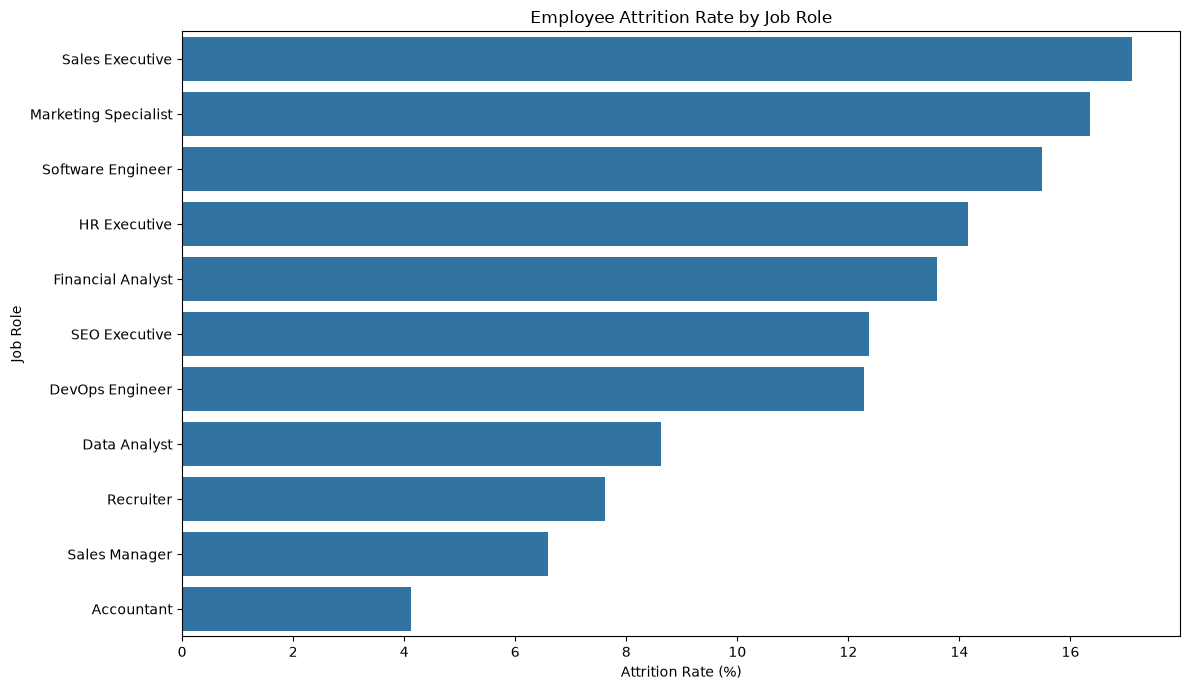

In [11]:
plt.figure(figsize=(12, 7))

sns.barplot(data=role_analysis, x="Attrition_Rate", y="Job_Role")

plt.title("Employee Attrition Rate by Job Role")
plt.xlabel("Attrition Rate (%)")
plt.ylabel("Job Role")

plt.tight_layout()
plt.show()

## Attrition by Overtime

In [12]:
overtime_analysis = (
    df.groupby("Overtime")
    .agg(
        Total_Employees=("Employee_ID", "count"),
        Employees_Left=("Attrition", lambda x: (x == "Yes").sum()),
    )
    .reset_index()
)

overtime_analysis["Attrition_Rate"] = (
    overtime_analysis["Employees_Left"] / overtime_analysis["Total_Employees"]
) * 100

overtime_analysis

,Overtime,Total_Employees,Employees_Left,Attrition_Rate
0,No,510,0,0.000000
1,Yes,490,118,24.081633


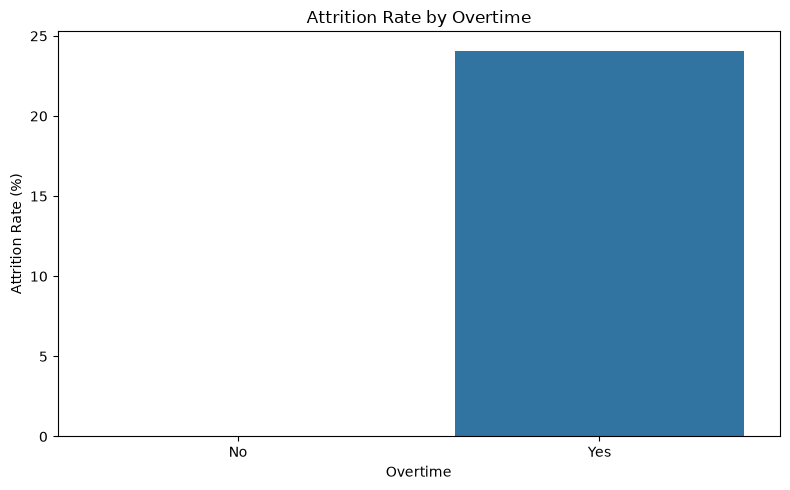

In [13]:
plt.figure(figsize=(8, 5))

sns.barplot(data=overtime_analysis, x="Overtime", y="Attrition_Rate")

plt.title("Attrition Rate by Overtime")
plt.xlabel("Overtime")
plt.ylabel("Attrition Rate (%)")

plt.tight_layout()
plt.show()

## Salary Distribution by Attrition

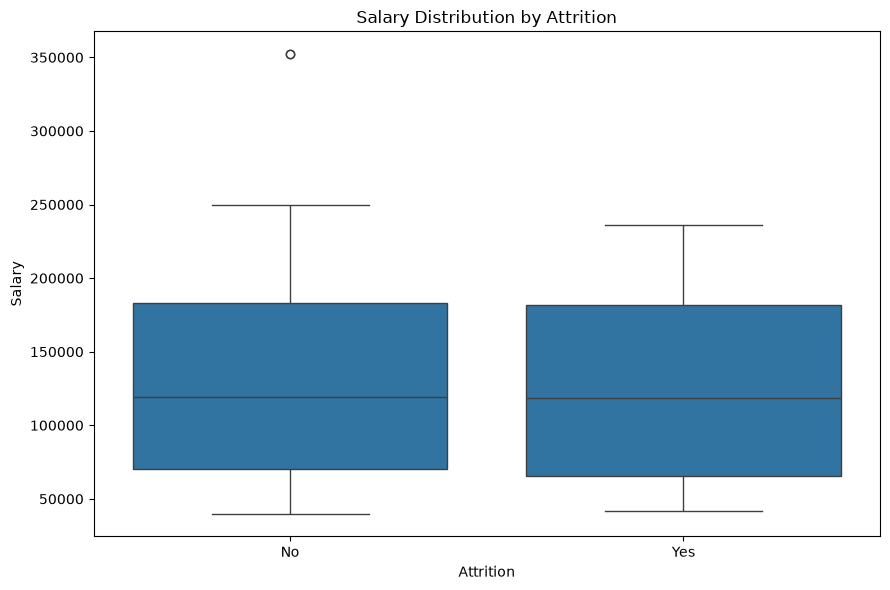

In [14]:
plt.figure(figsize=(9, 6))

sns.boxplot(data=df, x="Attrition", y="Salary")

plt.title("Salary Distribution by Attrition")
plt.xlabel("Attrition")
plt.ylabel("Salary")

plt.tight_layout()
plt.show()

## Experience Distribution by Attrition

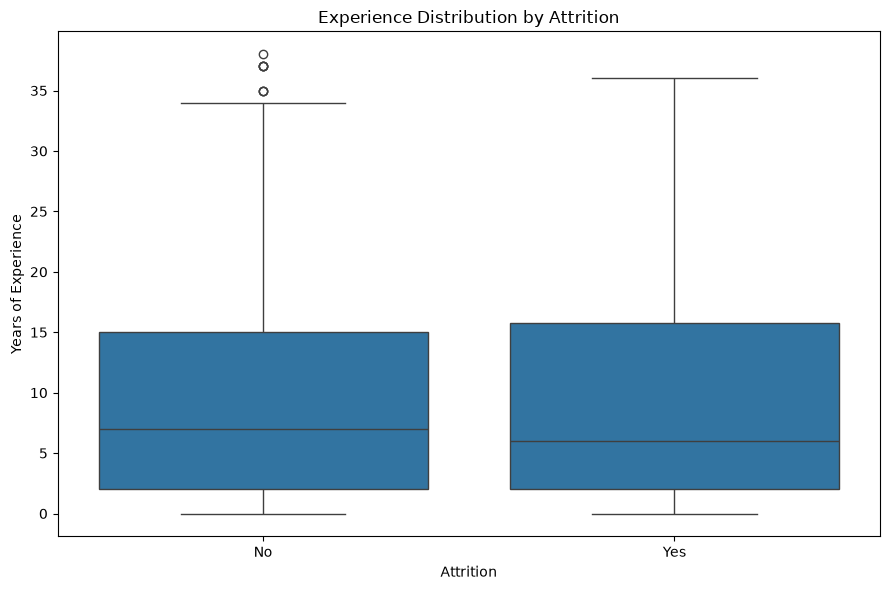

In [15]:
plt.figure(figsize=(9, 6))

sns.boxplot(data=df, x="Attrition", y="Experience")

plt.title("Experience Distribution by Attrition")
plt.xlabel("Attrition")
plt.ylabel("Years of Experience")

plt.tight_layout()
plt.show()

## Job Satisfaction and Attrition

In [ ]:
satisfaction_analysis = df.groupby("Attrition")["Job_Satisfaction"].mean().reset_index()

satisfaction_analysis

,Attrition,Job_Satisfaction
0,No,7.168934
1,Yes,3.576271


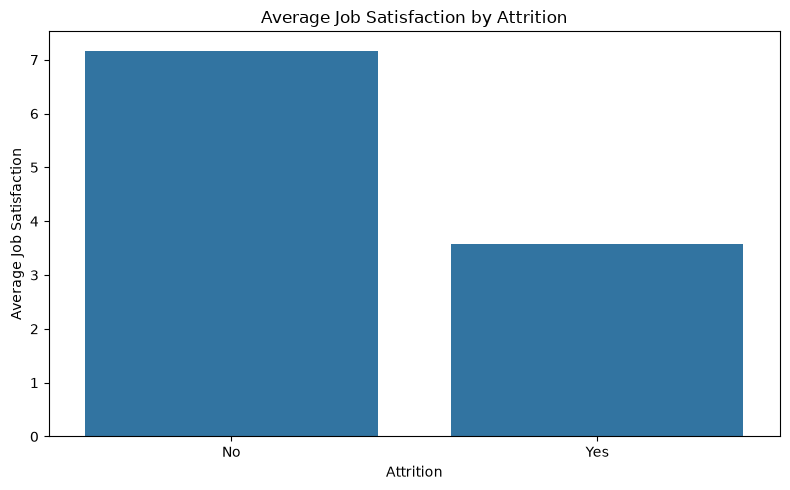

In [17]:
plt.figure(figsize=(8, 5))

sns.barplot(data=satisfaction_analysis, x="Attrition", y="Job_Satisfaction")

plt.title("Average Job Satisfaction by Attrition")
plt.xlabel("Attrition")
plt.ylabel("Average Job Satisfaction")

plt.tight_layout()
plt.show()

## Performance and Attrition

In [ ]:
performance_analysis = df.groupby("Attrition")["Performance_Score"].mean().reset_index()

performance_analysis

,Attrition,Performance_Score
0,No,2.995465
1,Yes,3.033898


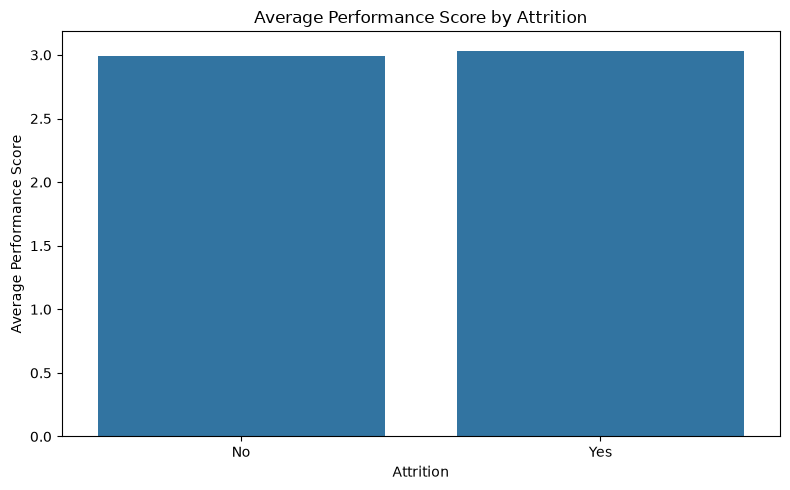

In [19]:
plt.figure(figsize=(8, 5))

sns.barplot(data=performance_analysis, x="Attrition", y="Performance_Score")

plt.title("Average Performance Score by Attrition")
plt.xlabel("Attrition")
plt.ylabel("Average Performance Score")

plt.tight_layout()
plt.show()

## Work Hours and Attrition

In [ ]:
work_hours_analysis = df.groupby("Attrition")["Work_Hours"].mean().reset_index()

work_hours_analysis

,Attrition,Work_Hours
0,No,44.829932
1,Yes,44.567797


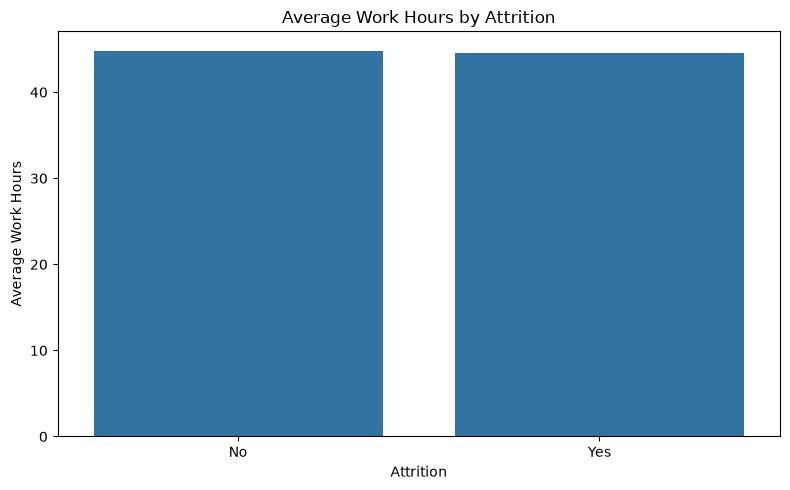

In [ ]:
plt.figure(figsize=(8, 5))

sns.barplot(data=work_hours_analysis, x="Attrition", y="Work_Hours")

plt.title("Average Work Hours by Attrition")
plt.xlabel("Attrition")
plt.ylabel("Average Work Hours")

plt.tight_layout()
plt.show()

## Training Hours and Attrition

In [ ]:
training_analysis = df.groupby("Attrition")["Training_Hours"].mean().reset_index()

training_analysis

,Attrition,Training_Hours
0,No,41.992063
1,Yes,42.144068


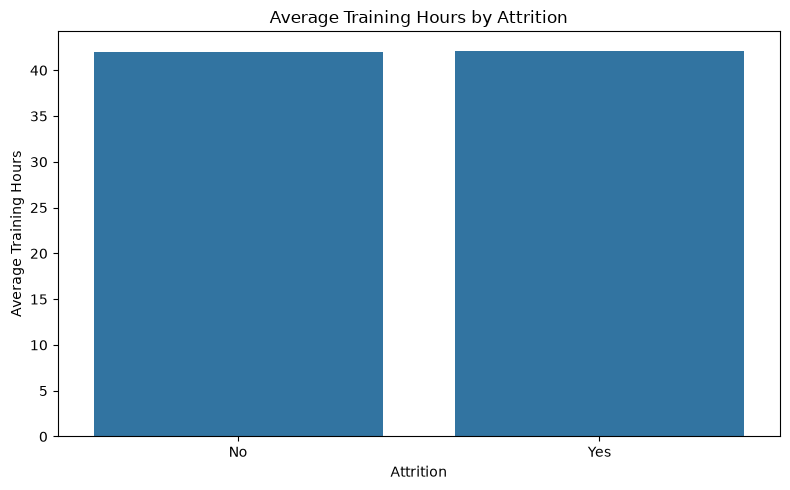

In [ ]:
plt.figure(figsize=(8, 5))

sns.barplot(data=training_analysis, x="Attrition", y="Training_Hours")

plt.title("Average Training Hours by Attrition")
plt.xlabel("Attrition")
plt.ylabel("Average Training Hours")

plt.tight_layout()
plt.show()

## Attrition Correlation Analysis

In [ ]:
correlation_df = df.copy()

correlation_df["Attrition_Flag"] = correlation_df["Attrition"].map({"No": 0, "Yes": 1})

numeric_columns = [
    "Age",
    "Experience",
    "Salary",
    "Performance_Score",
    "Job_Satisfaction",
    "Work_Hours",
    "Training_Hours",
    "Projects",
    "Manager_Rating",
    "Sick_Leaves",
    "Attrition_Flag",
]

correlation_matrix = correlation_df[numeric_columns].corr()

correlation_matrix

,Age,Experience,Salary,Performance_Score,Job_Satisfaction,Work_Hours,Training_Hours,Projects,Manager_Rating,Sick_Leaves,Attrition_Flag
Age,1.000000,0.633404,0.558417,0.045209,0.004943,0.028447,-0.016562,0.543484,0.003498,0.045730,-0.011283
Experience,0.633404,1.000000,0.820469,0.016889,-0.027620,0.003463,-0.033629,0.780838,0.016240,0.036400,0.003378
Salary,0.558417,0.820469,1.000000,0.039949,0.009400,0.012189,-0.046180,0.855107,0.024755,0.034670,-0.018628
Performance_Score,0.045209,0.016889,0.039949,1.000000,-0.002525,-0.017970,-0.001676,0.024726,0.004174,-0.022753,0.008781
Job_Satisfaction,0.004943,-0.027620,0.009400,-0.002525,1.000000,0.047596,0.014340,0.008355,-0.002531,-0.003472,-0.590388
Work_Hours,0.028447,0.003463,0.012189,-0.017970,0.047596,1.000000,0.010562,0.010473,-0.037924,0.013678,-0.013845
Training_Hours,-0.016562,-0.033629,-0.046180,-0.001676,0.014340,0.010562,1.000000,-0.042296,0.010390,0.011560,0.002189
Projects,0.543484,0.780838,0.855107,0.024726,0.008355,0.010473,-0.042296,1.000000,0.011567,0.032231,-0.028001
Manager_Rating,0.003498,0.016240,0.024755,0.004174,-0.002531,-0.037924,0.010390,0.011567,1.000000,0.018602,-0.000283
Sick_Leaves,0.045730,0.036400,0.034670,-0.022753,-0.003472,0.013678,0.011560,0.032231,0.018602,1.000000,-0.021886


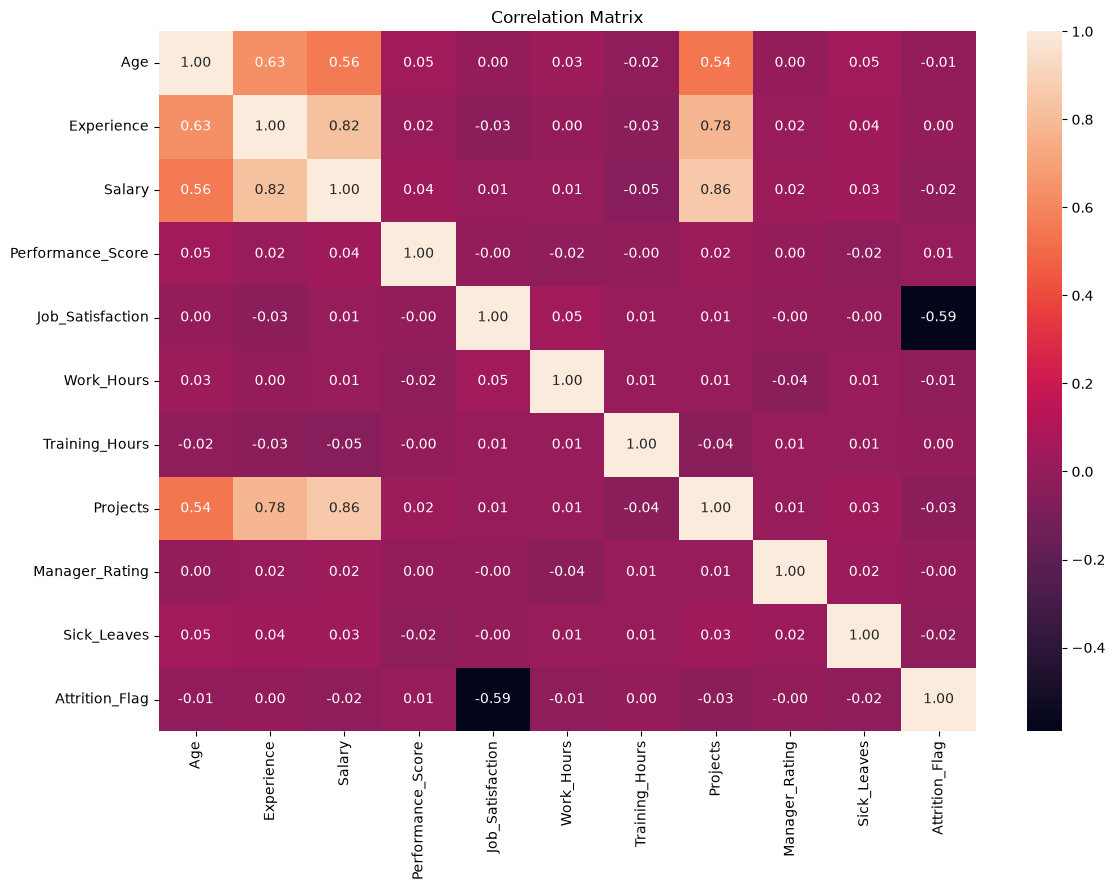

In [ ]:
plt.figure(figsize=(12, 9))

sns.heatmap(correlation_matrix, annot=True, fmt=".2f")

plt.title("Correlation Matrix")

plt.tight_layout()
plt.show()

## Attrition Correlation with Numeric Features

In [ ]:
attrition_correlations = (
    correlation_matrix["Attrition_Flag"]
    .drop("Attrition_Flag")
    .sort_values(ascending=False)
)

attrition_correlations

Performance_Score    0.008781
Experience           0.003378
Training_Hours       0.002189
Manager_Rating      -0.000283
Age                 -0.011283
Work_Hours          -0.013845
Salary              -0.018628
Sick_Leaves         -0.021886
Projects            -0.028001
Job_Satisfaction    -0.590388
Name: Attrition_Flag, dtype: float64

## Remote Work and Attrition

In [ ]:
remote_analysis = (
    df.groupby("Remote_Work")
    .agg(
        Total_Employees=("Employee_ID", "count"),
        Employees_Left=("Attrition", lambda x: (x == "Yes").sum()),
    )
    .reset_index()
)

remote_analysis["Attrition_Rate"] = (
    remote_analysis["Employees_Left"] / remote_analysis["Total_Employees"]
) * 100

remote_analysis

,Remote_Work,Total_Employees,Employees_Left,Attrition_Rate
0,No,499,61,12.224449
1,Yes,501,57,11.377246


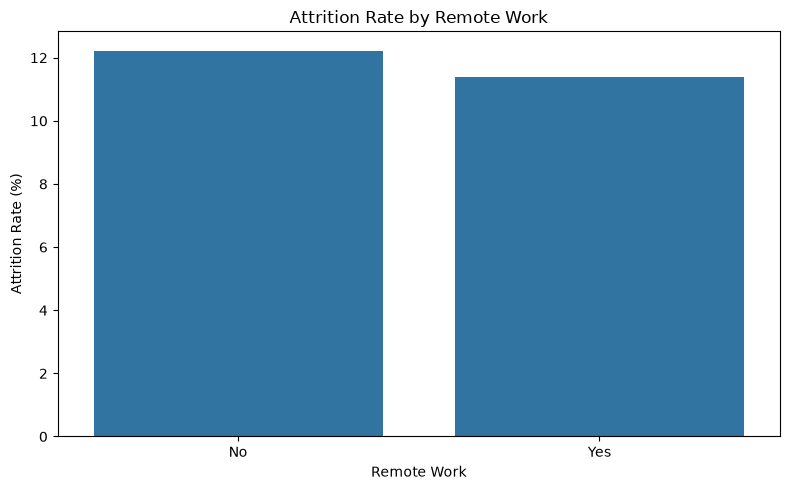

In [28]:
plt.figure(figsize=(8, 5))

sns.barplot(data=remote_analysis, x="Remote_Work", y="Attrition_Rate")

plt.title("Attrition Rate by Remote Work")
plt.xlabel("Remote Work")
plt.ylabel("Attrition Rate (%)")

plt.tight_layout()
plt.show()

## Promotion History and Attrition

In [29]:
promotion_analysis = (
    df.groupby("Promotion_Last_5Yrs")
    .agg(
        Total_Employees=("Employee_ID", "count"),
        Employees_Left=("Attrition", lambda x: (x == "Yes").sum()),
    )
    .reset_index()
)

promotion_analysis["Attrition_Rate"] = (
    promotion_analysis["Employees_Left"] / promotion_analysis["Total_Employees"]
) * 100

promotion_analysis

,Promotion_Last_5Yrs,Total_Employees,Employees_Left,Attrition_Rate
0,No,794,92,11.586902
1,Yes,206,26,12.621359


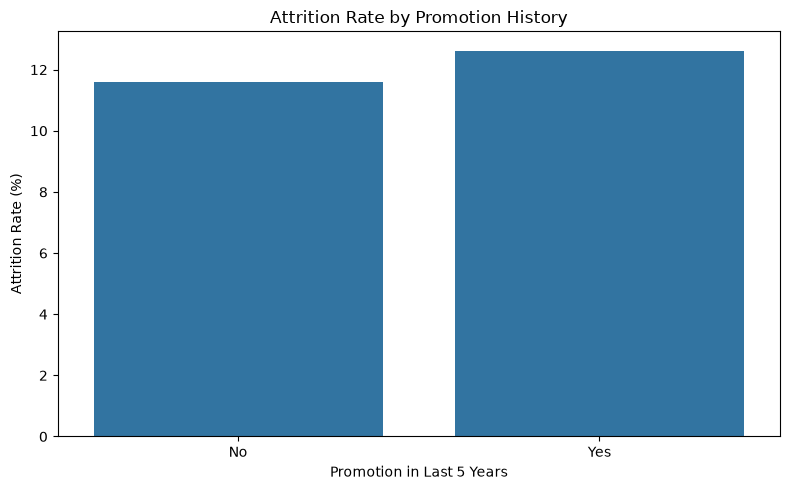

In [30]:
plt.figure(figsize=(8, 5))

sns.barplot(data=promotion_analysis, x="Promotion_Last_5Yrs", y="Attrition_Rate")

plt.title("Attrition Rate by Promotion History")
plt.xlabel("Promotion in Last 5 Years")
plt.ylabel("Attrition Rate (%)")

plt.tight_layout()
plt.show()

## Attrition by Employment Type

In [31]:
employment_analysis = (
    df.groupby("Employment_Type")
    .agg(
        Total_Employees=("Employee_ID", "count"),
        Employees_Left=("Attrition", lambda x: (x == "Yes").sum()),
    )
    .reset_index()
)

employment_analysis["Attrition_Rate"] = (
    employment_analysis["Employees_Left"] / employment_analysis["Total_Employees"]
) * 100

employment_analysis

,Employment_Type,Total_Employees,Employees_Left,Attrition_Rate
0,Contract,472,57,12.076271
1,Full-Time,528,61,11.553030


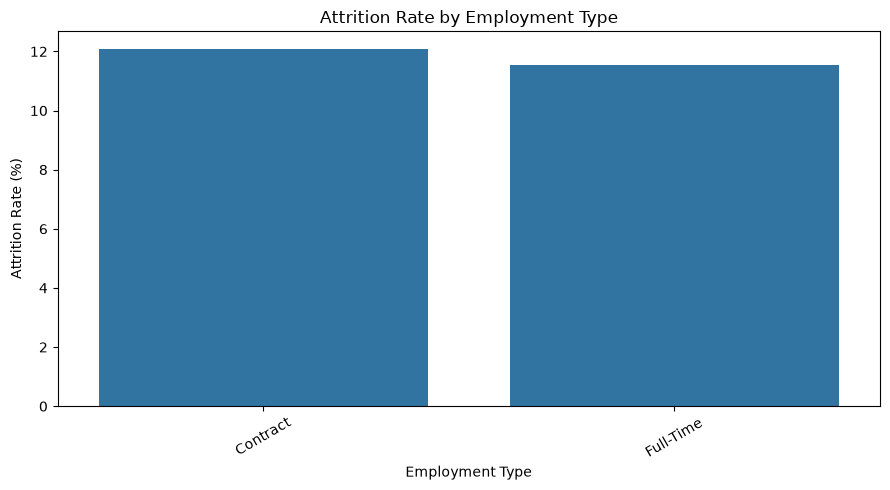

In [32]:
plt.figure(figsize=(9, 5))

sns.barplot(data=employment_analysis, x="Employment_Type", y="Attrition_Rate")

plt.title("Attrition Rate by Employment Type")
plt.xlabel("Employment Type")
plt.ylabel("Attrition Rate (%)")

plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

## City-Level Attrition

In [33]:
city_analysis = (
    df.groupby("City")
    .agg(
        Total_Employees=("Employee_ID", "count"),
        Employees_Left=("Attrition", lambda x: (x == "Yes").sum()),
    )
    .reset_index()
)

city_analysis["Attrition_Rate"] = (
    city_analysis["Employees_Left"] / city_analysis["Total_Employees"]
) * 100

city_analysis = city_analysis.sort_values("Attrition_Rate", ascending=False)

city_analysis

,City,Total_Employees,Employees_Left,Attrition_Rate
5,Rawalpindi,171,28,16.374269
0,Faisalabad,159,22,13.836478
4,Peshawar,187,22,11.764706
1,Islamabad,166,19,11.445783
3,Lahore,153,14,9.150327
2,Karachi,164,13,7.926829


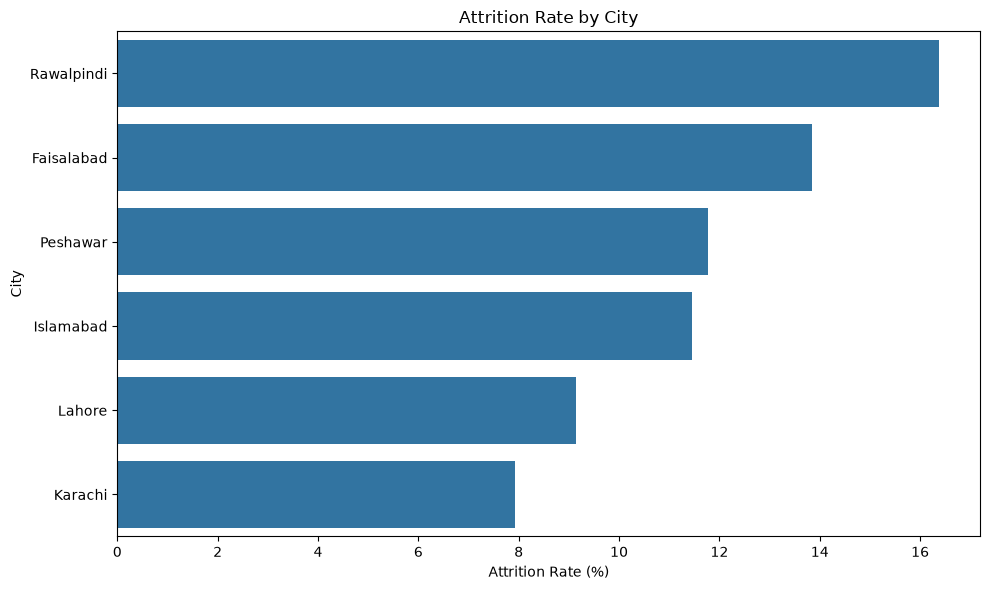

In [34]:
plt.figure(figsize=(10, 6))

sns.barplot(data=city_analysis, x="Attrition_Rate", y="City")

plt.title("Attrition Rate by City")
plt.xlabel("Attrition Rate (%)")
plt.ylabel("City")

plt.tight_layout()
plt.show()

## Key Visualization Findings

Use the charts above to identify:

- Departments with high attrition
- Job roles with high attrition
- Relationship between overtime and attrition
- Salary differences between employees who leave and stay
- Experience differences between employees who leave and stay
- Satisfaction differences
- Workload differences
- Training differences
- Remote work patterns
- Promotion patterns

In [35]:
print("Visualization analysis completed successfully.")
print()
print("Total Employees:", len(df))
print("Employees Left:", (df["Attrition"] == "Yes").sum())
print("Overall Attrition Rate:", round(attrition_rate, 2), "%")

Visualization analysis completed successfully.

Total Employees: 1000
Employees Left: 118
Overall Attrition Rate: 11.8 %
